In [14]:
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [11]:
readbag = bagreader('/home/henrypcl/rosbag/dsr_path2.bag')
print(readbag.topic_table)

[INFO]  Data folder /home/henrypcl/rosbag/dsr_path2 already exists. Not creating.
                       Topics                       Types  Message Count  \
0   /tbot149/april_data_multi  std_msgs/Float32MultiArray           2141   
1               /tbot149/data         geometry_msgs/Twist           2141   
2             /tbot149/l_traj  std_msgs/Float32MultiArray           2141   
3               /tbot149/odom           nav_msgs/Odometry           4686   
4             /tbot149/target         geometry_msgs/Point           2140   
5   /tbot162/april_data_multi  std_msgs/Float32MultiArray           2030   
6               /tbot162/data         geometry_msgs/Twist           2140   
7             /tbot162/l_traj  std_msgs/Float32MultiArray           2140   
8               /tbot162/odom           nav_msgs/Odometry           5234   
9             /tbot162/target         geometry_msgs/Point           2140   
10              /tbot165/odom           nav_msgs/Odometry           5656   
11  /t

In [49]:
odom165 = readbag.message_by_topic('/tbot165/odom')
odom165_data = pd.read_csv(odom165)
pos_x_165 = odom165_data['pose.pose.position.x']
pos_y_165 = odom165_data['pose.pose.position.y']
head_165  = odom165_data['pose.pose.orientation.z']

odom149 = readbag.message_by_topic('/tbot149/odom')
odom149_data = pd.read_csv(odom149)
pos_x_149 = odom149_data['pose.pose.position.x']
pos_y_149 = odom149_data['pose.pose.position.y']
head_149  = odom149_data['pose.pose.orientation.z']

odom201 = readbag.message_by_topic('/tbot201/odom')
odom201_data = pd.read_csv(odom201)
pos_x_201 = odom201_data['pose.pose.position.x']
pos_y_201 = odom201_data['pose.pose.position.y']
head_201  = odom201_data['pose.pose.orientation.z']

odom162 = readbag.message_by_topic('/tbot162/odom')
odom162_data = pd.read_csv(odom162)
pos_x_162 = odom162_data['pose.pose.position.x']
pos_y_162 = odom162_data['pose.pose.position.y']
head_162  = odom162_data['pose.pose.orientation.z']

### Plot robot trajectory

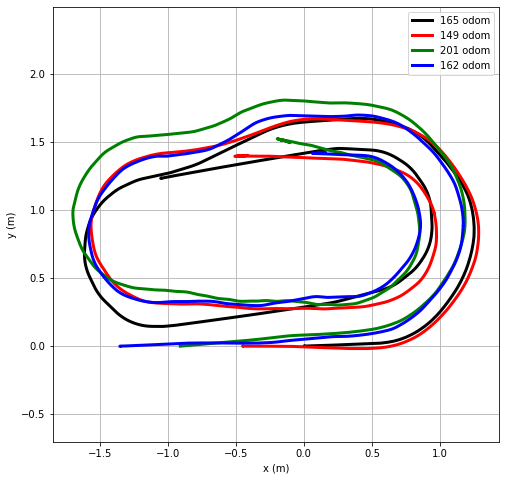

In [44]:
d = 0.45

plt.figure(figsize=(8,8))
plt.plot(pos_x_165,     pos_y_165,'k-', linewidth=3,label='165 odom')
plt.plot(pos_x_149-d,   pos_y_149,'r-', linewidth=3,label='149 odom')
plt.plot(pos_x_201-2*d, pos_y_201,'g-', linewidth=3,label='201 odom')
plt.plot(pos_x_162-3*d, pos_y_162,'b-', linewidth=3,label='162 odom')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
plt.legend()
plt.grid()

### Plot relative angle

In [53]:
print(len(head_165),len(head_149),len(head_201),len(head_162))

5656 4686 2974 5234
